## Loading the Fine-Tuned Model

In [ ]:
!pip install -q transformers peft accelerate bitsandbytes

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from datasets import load_dataset
from peft import PeftModel

# load the dataset
ds = load_dataset("gretelai/synthetic_text_to_sql")

base_model_name = "Qwen/Qwen2.5-1.5B-Instruct"
adapter_repo = "Amr-Kh-2004/Qwen2.5-1.5B-Instruct-text2sql-lora"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

tokenizer = AutoTokenizer.from_pretrained(adapter_repo)

base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    quantization_config=quantization_config,
    torch_dtype=torch.float16,
)

model = PeftModel.from_pretrained(base_model, adapter_repo)
model.eval()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 11.9 MB/s eta 0:00:00


README.md:   0%|          | 0.00/8.19k [00:00<?, ?B/s]

synthetic_text_to_sql_train.snappy.parqu(…): reconstructing file:   0%|          |  0.00B / 32.4MB            

synthetic_text_to_sql_train.snappy.parqu(…): downloading bytes:           |  0.00B            

synthetic_text_to_sql_test.snappy.parque(…): reconstructing file:   0%|          |  0.00B / 1.90MB            

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/1.31k [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B / 37.0MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(151936, 1536)
        (layers): ModuleList(
          (0-27): 28 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=1536, out_features=1536, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=1536, out_features=8, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=8, out_features=1536, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear4bit(
         

## Custom Evaluation Function

In [ ]:
import re

def sanitize_sql_for_sqlite(sql_str: str) -> str:
    if not sql_str:
        return ""

    # 1. Extract schema names (e.g., CREATE SCHEMA defense;)
    schemas = re.findall(r'(?i)CREATE\s+SCHEMA\s+(?:IF\s+NOT\s+EXISTS\s+)?([a-zA-Z0-9_]+)', sql_str)

    # 2. Strip CREATE and DROP SCHEMA statements
    sql = re.sub(r'(?i)(CREATE|DROP)\s+SCHEMA\s+[^;]+;', '', sql_str)

    # 3. Strip extracted schema prefixes (e.g., "defense.table_name" -> "table_name")
    for schema in schemas:
        sql = re.sub(rf'\b{re.escape(schema)}\.', '', sql)

    # 4. Fallback schema prefix cleanup for table targets (CREATE/INTO/FROM/JOIN)
    sql = re.sub(r'(?i)\b(TABLE|INTO|UPDATE|FROM|JOIN)\s+([a-zA-Z0-9_]+)\.', r'\1 ', sql)

    # 5. Remove Postgres typecasts (e.g., '2026-01-01'::DATE or col::TEXT)
    sql = re.sub(r'::\s*[a-zA-Z0-9_]+', '', sql)

    # 6. Translate keywords and data types
    sql = re.sub(r'\bILIKE\b', 'LIKE', sql, flags=re.IGNORECASE)
    sql = re.sub(r'\b(BIG)?SERIAL\b', 'INTEGER', sql, flags=re.IGNORECASE)
    sql = re.sub(r'\bTIMESTAMP(\s+WITH\s+TIME\s+ZONE)?\b', 'DATETIME', sql, flags=re.IGNORECASE)

    return sql

In [ ]:
import sqlite3
from collections import Counter

def validate_and_evaluate(schema_script: str, pred_sql: str, target_sql: str) -> dict:
    conn = sqlite3.connect(":memory:")
    cursor = conn.cursor()

    status = {
        "target_executes": False,
        "pred_executes": False,
        "exact_data_match": False,
        "error": None,
    }

    try:
        cursor.executescript(sanitize_sql_for_sqlite(schema_script))

        try:
            cursor.execute(sanitize_sql_for_sqlite(target_sql))
            target_results = cursor.fetchall()
            status["target_executes"] = True
        except sqlite3.Error as e:
            status["error"] = f"target: {e}"
            return status

        try:
            cursor.execute(sanitize_sql_for_sqlite(pred_sql))
            pred_results = cursor.fetchall()
            status["pred_executes"] = True
        except sqlite3.Error as e:
            status["error"] = f"pred: {e}"
            return status

        # Counter compares row multiplicities, not just set membership --
        # a result missing/adding a duplicate row will now correctly count as a mismatch
        status["exact_data_match"] = Counter(pred_results) == Counter(target_results)

    except sqlite3.Error as e:
        status["error"] = f"schema: {e}"
    finally:
        conn.close()

    return status


## Execution-accuracy loop

In [ ]:
def generate_sql(example, model, tokenizer, max_new_tokens=256):
    chat = [
        {"role": "system", "content": "You are an SQL query generator given a question and a database schema, generate an SQL query."},
        {"role": "user", "content": f"Question: {example['sql_prompt']}\nDatabase Schema: {example['sql_context']}\nSQL Query:"},
    ]
    prompt = tokenizer.apply_chat_template(chat, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]
    output = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return tokenizer.decode(output[0][input_len:], skip_special_tokens=True)

def query_complexity(sql: str) -> str:
    sql_upper = sql.upper()
    has_join = "JOIN" in sql_upper
    has_group = "GROUP BY" in sql_upper
    has_order = "ORDER BY" in sql_upper or "LIMIT" in sql_upper

    if has_join and has_group:
        return "JOIN + GROUP BY"
    if has_join:
        return "JOIN"
    if has_group:
        return "GROUP BY"
    if has_order:
        return "ORDER BY / LIMIT"
    return "simple"

In [ ]:
from tqdm.auto import tqdm

def calc_acc(results):
  denom = n_exec_samples - results["target_failed"]  # exclude cases where our sanitizer, not the model, is at fault
  execution_accuracy = results["match"] / denom if denom else float("nan")
  return execution_accuracy

def model_accuracy(exec_subset, model, tokenizer, label="model"):
    results = {"match": 0, "wrong_result": 0, "pred_failed": 0, "target_failed": 0}
    per_example_rows = []  # one row per example, for later analysis / plotting
    failed_examples = []

    for example in tqdm(exec_subset, desc=label):
        predicted_sql = generate_sql(example, model, tokenizer)
        outcome = validate_and_evaluate(
            schema_script=example["sql_context"],
            pred_sql=predicted_sql,
            target_sql=example["sql"],
        )

        if not outcome["target_executes"]:
            category = "target_failed"
        elif not outcome["pred_executes"]:
            category = "pred_failed"
            failed_examples.append((example, predicted_sql, outcome))
        elif outcome["exact_data_match"]:
            category = "match"
        else:
            category = "wrong_result"
            failed_examples.append((example, predicted_sql, outcome))

        results[category] += 1
        per_example_rows.append({
            "model": label,
            "complexity": query_complexity(example["sql"]),
            "outcome": category,
        })

    denom = len(exec_subset) - results["target_failed"]
    accuracy = results["match"] / denom if denom else float("nan")
    print(f"{label} execution accuracy: {accuracy:.2%}  {results}")

    return results, failed_examples, per_example_rows


In [ ]:
import pandas as pd
import transformers
transformers.logging.set_verbosity_error()

n_exec_samples = 500
exec_subset = ds["test"].select(range(n_exec_samples))

# Base model: adapters disabled
with model.disable_adapter():
    original_results, original_failed, original_rows = model_accuracy(
        exec_subset, model, tokenizer, label="Base"
    )

# Fine-tuned: adapters enabled
ft_results, ft_failed, ft_rows = model_accuracy(
    exec_subset, model, tokenizer, label="Fine-tuned"
)

eval_df = pd.DataFrame(original_rows + ft_rows)

Base:   0%|          | 0/500 [00:00<?, ?it/s]

Base execution accuracy: 7.27%  {'match': 29, 'wrong_result': 10, 'pred_failed': 360, 'target_failed': 101}


Fine-tuned:   0%|          | 0/500 [00:00<?, ?it/s]

Fine-tuned execution accuracy: 67.67%  {'match': 270, 'wrong_result': 88, 'pred_failed': 41, 'target_failed': 101}


## Comparing the Base and the Fine-Tuned Models

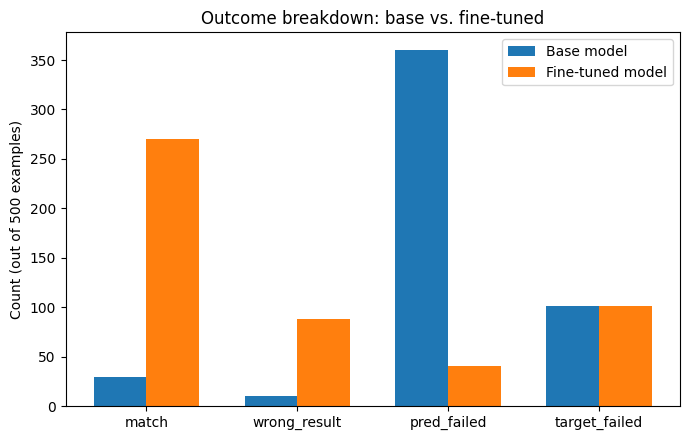

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

categories = ["match", "wrong_result", "pred_failed", "target_failed"]
base_counts = [original_results[c] for c in categories]
ft_counts = [ft_results[c] for c in categories]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width/2, base_counts, width, label="Base model")
ax.bar(x + width/2, ft_counts, width, label="Fine-tuned model")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylabel("Count (out of 500 examples)")
ax.set_title("Outcome breakdown: base vs. fine-tuned")
ax.legend()
plt.tight_layout()
plt.savefig("outcome_breakdown2.png", dpi=150, bbox_inches="tight")
plt.show()


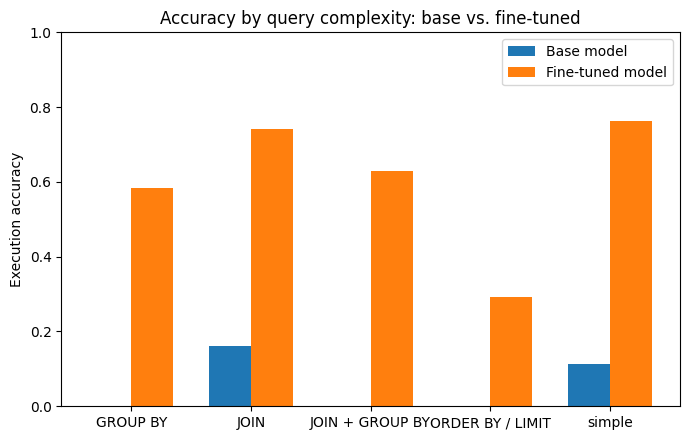

In [ ]:
def accuracy_by_complexity(df, model_label):
    sub = df[df["model"] == model_label]
    out = {}
    for complexity, group in sub.groupby("complexity"):
        denom = (group["outcome"] != "target_failed").sum()
        matches = (group["outcome"] == "match").sum()
        out[complexity] = matches / denom if denom else float("nan")
    return out

base_by_complexity = accuracy_by_complexity(eval_df, "Base")
ft_by_complexity = accuracy_by_complexity(eval_df, "Fine-tuned")

complexities = sorted(set(base_by_complexity) | set(ft_by_complexity))
base_acc = [base_by_complexity.get(c, 0) for c in complexities]
ft_acc = [ft_by_complexity.get(c, 0) for c in complexities]

x = np.arange(len(complexities))
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(x - width/2, base_acc, width, label="Base model")
ax.bar(x + width/2, ft_acc, width, label="Fine-tuned model")
ax.set_xticks(x)
ax.set_xticklabels(complexities)
ax.set_ylabel("Execution accuracy")
ax.set_ylim(0, 1)
ax.set_title("Accuracy by query complexity: base vs. fine-tuned")
ax.legend()
plt.tight_layout()
plt.savefig("outcome_breakdown1.png", dpi=200, bbox_inches="tight")
plt.show()
